<a href="https://colab.research.google.com/github/WONDERWOMAN2k/NLP_SentimentAnalysis/blob/main/AI_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Install necessary libraries (run only once)
!pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from wordcloud import WordCloud
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('chatgpt_reviews - chatgpt_reviews.csv')  # Replace with your actual file path
df.head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Saving chatgpt_reviews - chatgpt_reviews.csv to chatgpt_reviews - chatgpt_reviews (3).csv


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,2/15/2025,Impressive,Mother former community upon vote fact. Sure s...,2,ybass,68,78,Mobile,es,Canada,3.0,No
1,10/16/2024,Waste of Time,General paper understand main. Or age half won...,5,glenn33,71,193,Web,de,India,4.1,Yes
2,10/16/2024,Waste of Time,Here situation his high stage. Agree certainly...,4,debbie27,66,184,Web,hi,India,4.1,Yes
3,12/21/2024,Not Accurate,Rule court behind growth reality. Tonight whos...,1,hannahrussell,5,193,Web,fr,Canada,4.0,Yes
4,3/23/2025,Fantastic Experience,Case opportunity season road write. Effort gre...,3,cnorton,71,131,Web,hi,Australia,4.1,No


In [21]:
import shutil
shutil.rmtree('/root/nltk_data', ignore_errors=True)


In [22]:
import nltk

# Re-download the correct resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [28]:
print(df.columns)


Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase'],
      dtype='object')


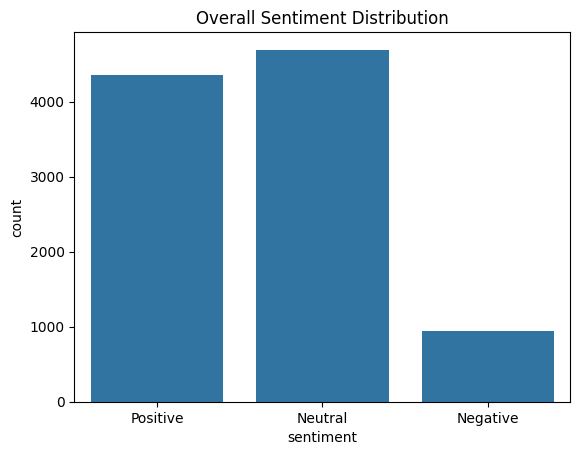

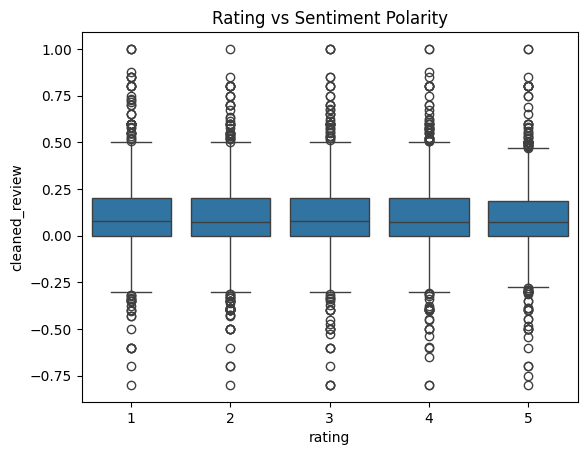

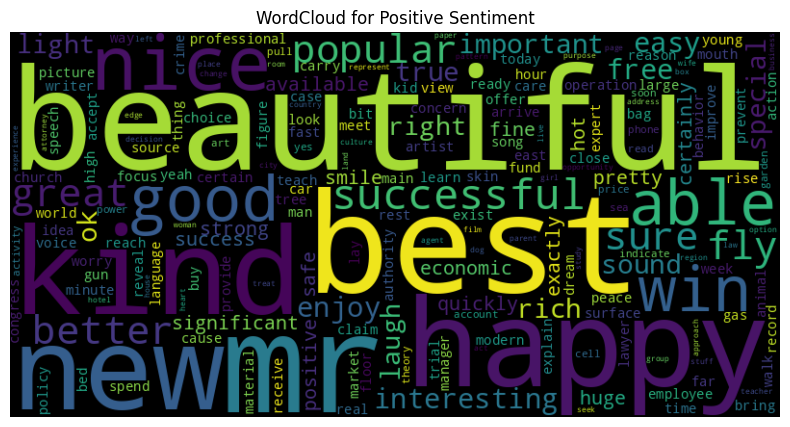

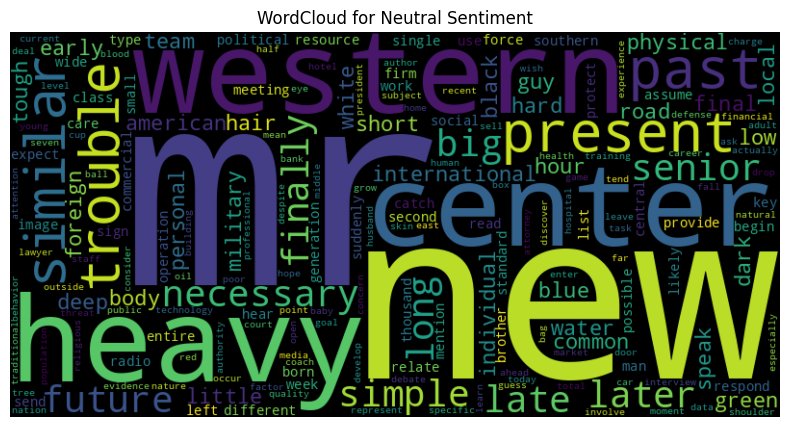

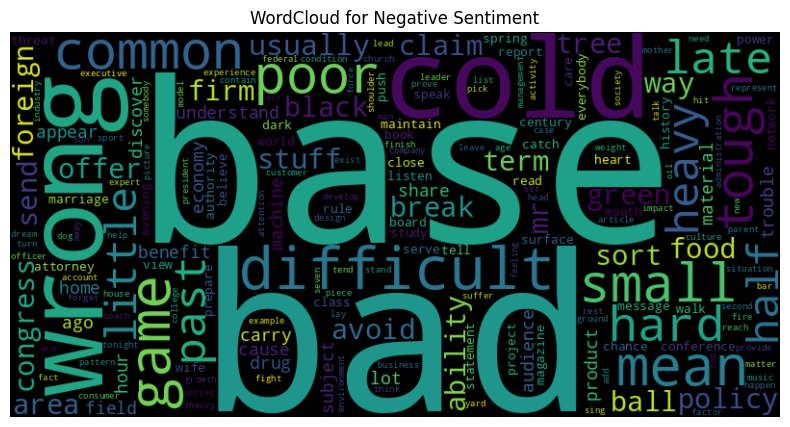

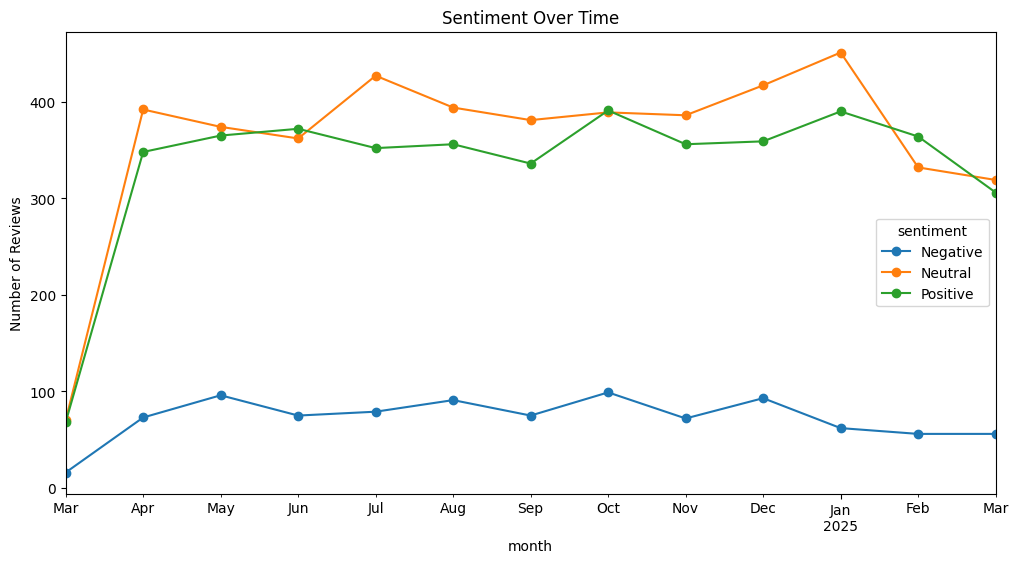

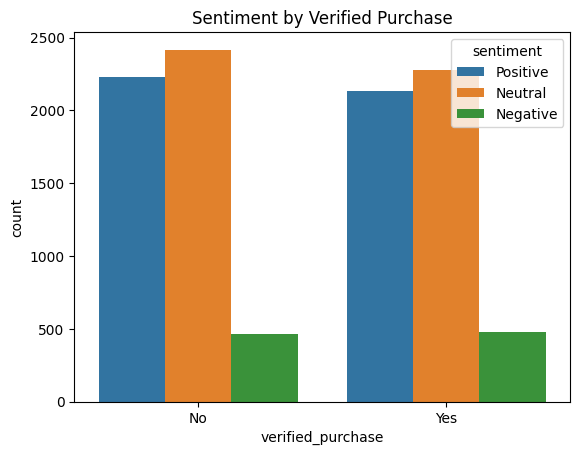

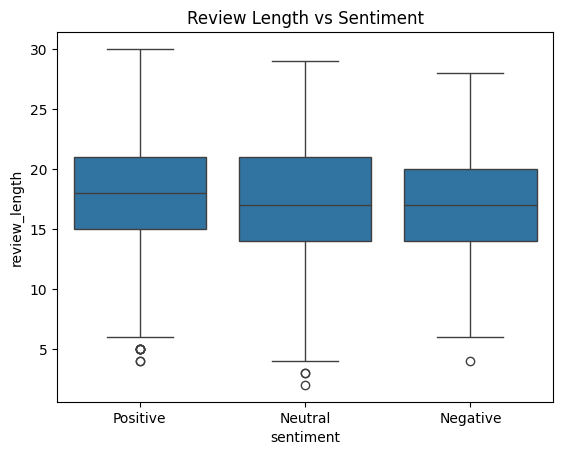

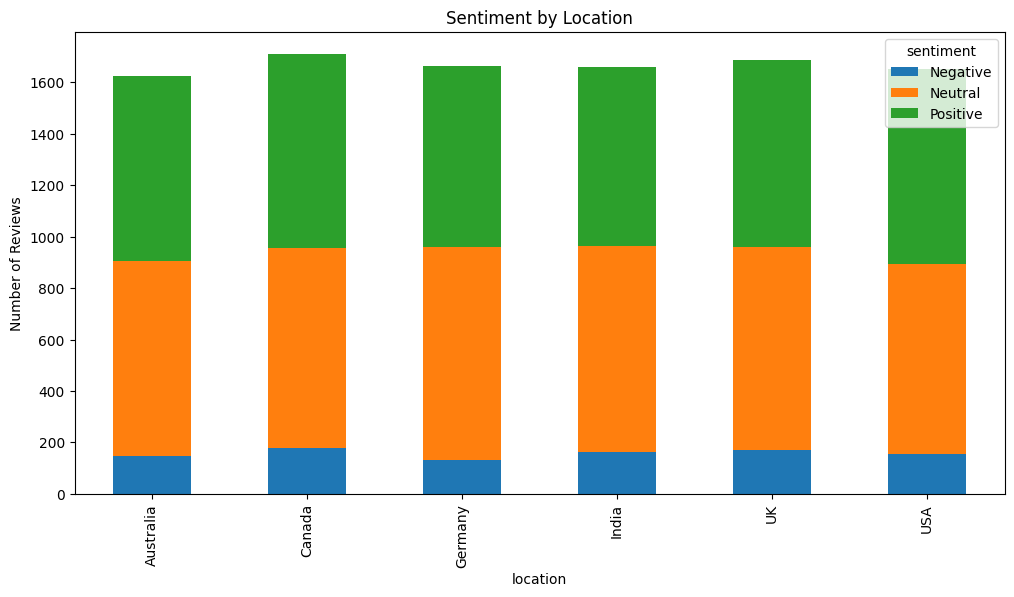

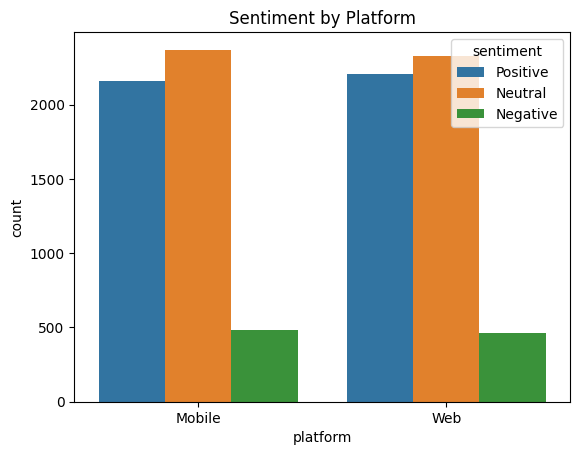

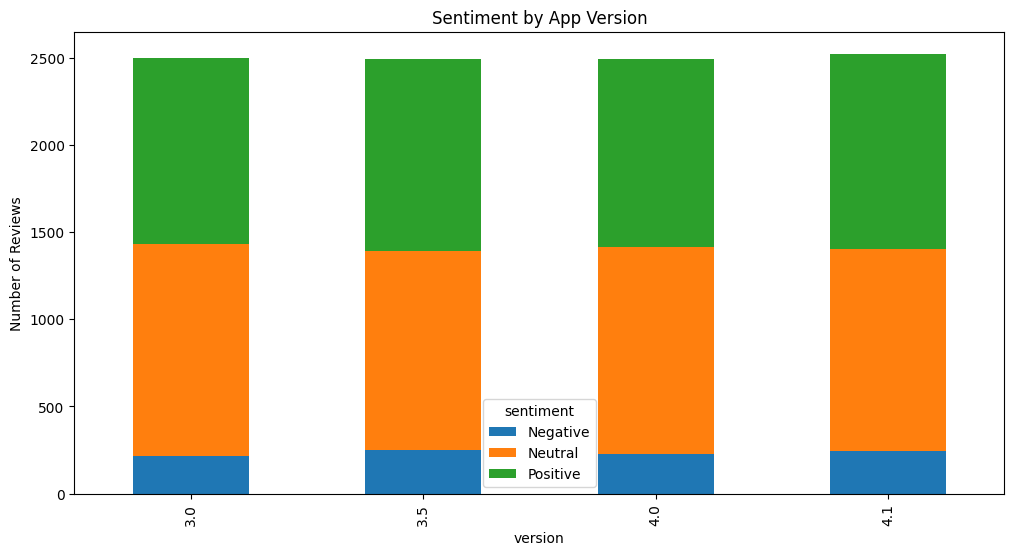


Topic #1:
['poor', 'performance', 'explain', 'leader', 'music', 'difficult', 'stuff', 'small', 'wrong', 'base']

Topic #2:
['game', 'measure', 'push', 'tend', 'son', 'mean', 'continue', 'past', 'common', 'bad']

Topic #3:
['food', 'investment', 'late', 'machine', 'difficult', 'trouble', 'sit', 'mean', 'bad', 'cold']

Topic #4:
['message', 'age', 'game', 'forget', 'difficult', 'arm', 'little', 'management', 'common', 'bad']

Topic #5:
['hard', 'heavy', 'remember', 'half', 'sort', 'game', 'cold', 'tough', 'bad', 'base']


In [31]:
# AI Echo: ChatGPT User Review Sentiment Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import spacy
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Load spaCy English model
import en_core_web_sm
nlp = en_core_web_sm.load()

# Load dataset
df = pd.read_csv('chatgpt_reviews - chatgpt_reviews.csv')  # Replace with your actual path

# Preprocessing with spaCy
def preprocess(text):
    doc = nlp(str(text).lower())
    stop_words = spacy.lang.en.stop_words.STOP_WORDS
    return " ".join([token.text for token in doc if token.is_alpha and token.text not in stop_words])

# Apply preprocessing
df['cleaned_review'] = df['review'].astype(str).apply(preprocess)

# 1. Sentiment Classification
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['cleaned_review'].apply(get_sentiment)

# Plot Sentiment Distribution
sns.countplot(data=df, x='sentiment')
plt.title('Overall Sentiment Distribution')
plt.show()

# 2. Sentiment vs Rating
sns.boxplot(data=df, x='rating', y=df['cleaned_review'].apply(lambda x: TextBlob(x).sentiment.polarity))
plt.title("Rating vs Sentiment Polarity")
plt.show()

# 3. WordCloud for each sentiment
for sentiment in ['Positive', 'Neutral', 'Negative']:
    text = " ".join(df[df['sentiment'] == sentiment]['cleaned_review'])
    wordcloud = WordCloud(width=800, height=400).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for {sentiment} Sentiment")
    plt.show()

# 4. Sentiment Over Time
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
sentiment_trend = df.groupby(['month', 'sentiment']).size().unstack().fillna(0)
sentiment_trend.plot(figsize=(12,6), marker='o')
plt.title('Sentiment Over Time')
plt.ylabel('Number of Reviews')
plt.show()

# 5. Verified vs Non-Verified
sns.countplot(data=df, x='verified_purchase', hue='sentiment')
plt.title('Sentiment by Verified Purchase')
plt.show()

# 6. Review Length vs Sentiment
df['review_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))
sns.boxplot(data=df, x='sentiment', y='review_length')
plt.title('Review Length vs Sentiment')
plt.show()

# 7. Location-based Sentiment
location_sentiment = df.groupby(['location', 'sentiment']).size().unstack().fillna(0)
location_sentiment.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Sentiment by Location')
plt.ylabel('Number of Reviews')
plt.show()

# 8. Platform-Based Sentiment
sns.countplot(data=df, x='platform', hue='sentiment')
plt.title('Sentiment by Platform')
plt.show()

# 9. Version-Based Sentiment
version_sentiment = df.groupby(['version', 'sentiment']).size().unstack().fillna(0)
version_sentiment.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Sentiment by App Version')
plt.ylabel('Number of Reviews')
plt.show()

# 10. Topic Modeling for Negative Reviews
negative_reviews = df[df['sentiment'] == 'Negative']['cleaned_review']
cv = CountVectorizer(max_df=0.9, min_df=2, stop_words='english')
dtm = cv.fit_transform(negative_reviews)
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

# Display Topics
words = cv.get_feature_names_out()
for index, topic in enumerate(lda.components_):
    print(f"\nTopic #{index + 1}:")
    print([words[i] for i in topic.argsort()[-10:]])
